# Brazilian Serie A — XGBoost Match Outcome Predictor

**Goal:** Predict the match result (Home win / Draw / Away win) using feature engineering on historical team form and bookmaker odds.

**Dataset:** `BRA.csv` — Brazilian Serie A, 2012–2025  
**Target:** `Res` → H (Home win), D (Draw), A (Away win)

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')

## 2. Load Data

In [ ]:
df = pd.read_csv('BRA.csv', encoding='utf-8-sig')

# Parse date and sort chronologically — critical for leakage-free feature engineering
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df = df.sort_values('Date').reset_index(drop=True)

print(f'Shape: {df.shape}')
df.head()

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5386 entries, 0 to 5385
Data columns (total 25 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Country  5386 non-null   object        
 1   League   5386 non-null   object        
 2   Season   5386 non-null   int64         
 3   Date     5386 non-null   datetime64[ns]
 4   Time     5386 non-null   object        
 5   Home     5386 non-null   object        
 6   Away     5386 non-null   object        
 7   HG       5385 non-null   float64       
 8   AG       5385 non-null   float64       
 9   Res      5385 non-null   object        
 10  PSCH     5275 non-null   float64       
 11  PSCD     5275 non-null   float64       
 12  PSCA     5275 non-null   float64       
 13  MaxCH    5386 non-null   float64       
 14  MaxCD    5386 non-null   float64       
 15  MaxCA    5386 non-null   float64       
 16  AvgCH    5386 non-null   float64       
 17  AvgCD    5386 non-null   float64 

## 3. EDA

In [4]:
# Drop row with no result (future or abandoned match)
df = df[df['Res'].isin(['H', 'D', 'A'])].copy()
print(f'Rows after removing invalid results: {len(df)}')

print('\nResult distribution:')
print(df['Res'].value_counts())
print(df['Res'].value_counts(normalize=True).round(3))

Rows after removing invalid results: 5385

Result distribution:
Res
H    2612
D    1447
A    1326
Name: count, dtype: int64
Res
H    0.485
D    0.269
A    0.246
Name: proportion, dtype: float64


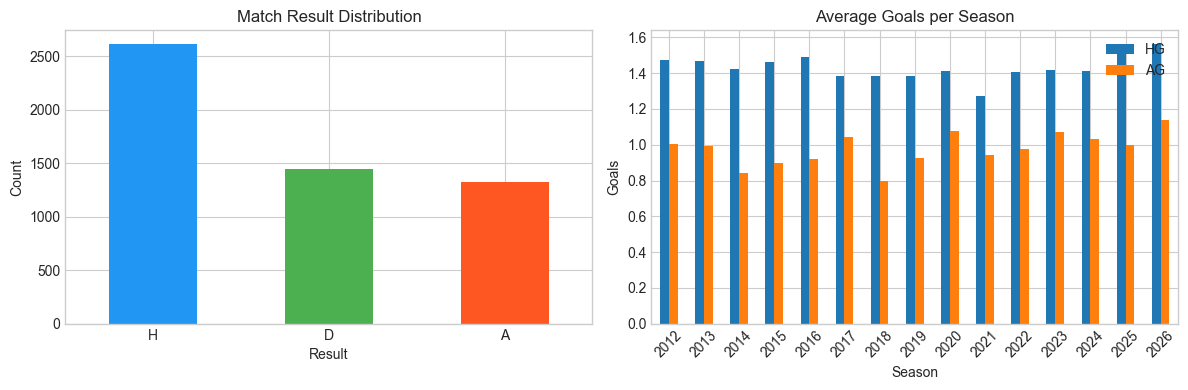

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['Res'].value_counts().plot(kind='bar', ax=axes[0], color=['#2196F3', '#4CAF50', '#FF5722'])
axes[0].set_title('Match Result Distribution')
axes[0].set_xlabel('Result')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

goals_per_season = df.groupby('Season')[['HG', 'AG']].mean()
goals_per_season.plot(kind='bar', ax=axes[1])
axes[1].set_title('Average Goals per Season')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Goals')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [6]:
# Odds availability
odds_cols = ['PSCH', 'PSCD', 'PSCA', 'MaxCH', 'MaxCD', 'MaxCA', 'AvgCH', 'AvgCD', 'AvgCA']
print('Missing values in odds columns:')
print(df[odds_cols].isnull().sum())

Missing values in odds columns:
PSCH     110
PSCD     110
PSCA     110
MaxCH      0
MaxCD      0
MaxCA      0
AvgCH      0
AvgCD      0
AvgCA      0
dtype: int64


## 4. Feature Engineering

### 4.1 Implied Probability from Bookmaker Odds

Bookmaker odds encode the probability of each outcome. We convert them to implied probabilities using the formula:  
`implied_prob = 1 / odds`  
then normalise to remove the overround (bookmaker margin).

In [7]:
def implied_probs(home_odds, draw_odds, away_odds):
    """Convert decimal odds to normalised implied probabilities."""
    raw_h = 1 / home_odds
    raw_d = 1 / draw_odds
    raw_a = 1 / away_odds
    total = raw_h + raw_d + raw_a
    return raw_h / total, raw_d / total, raw_a / total


# Pinnacle (most accurate, fewest missing)
ps_mask = df[['PSCH', 'PSCD', 'PSCA']].notna().all(axis=1)
df.loc[ps_mask, 'ps_prob_h'], df.loc[ps_mask, 'ps_prob_d'], df.loc[ps_mask, 'ps_prob_a'] = (
    implied_probs(df.loc[ps_mask, 'PSCH'], df.loc[ps_mask, 'PSCD'], df.loc[ps_mask, 'PSCA'])
)

# Average market odds
avg_mask = df[['AvgCH', 'AvgCD', 'AvgCA']].notna().all(axis=1)
df.loc[avg_mask, 'avg_prob_h'], df.loc[avg_mask, 'avg_prob_d'], df.loc[avg_mask, 'avg_prob_a'] = (
    implied_probs(df.loc[avg_mask, 'AvgCH'], df.loc[avg_mask, 'AvgCD'], df.loc[avg_mask, 'AvgCA'])
)

# Max odds (best value, different signal)
max_mask = df[['MaxCH', 'MaxCD', 'MaxCA']].notna().all(axis=1)
df.loc[max_mask, 'max_prob_h'], df.loc[max_mask, 'max_prob_d'], df.loc[max_mask, 'max_prob_a'] = (
    implied_probs(df.loc[max_mask, 'MaxCH'], df.loc[max_mask, 'MaxCD'], df.loc[max_mask, 'MaxCA'])
)

print('Implied probability features created.')
df[['ps_prob_h', 'ps_prob_d', 'ps_prob_a', 'avg_prob_h', 'avg_prob_d', 'avg_prob_a']].describe().round(3)

Implied probability features created.


,ps_prob_h,ps_prob_d,ps_prob_a,avg_prob_h,avg_prob_d,avg_prob_a
count,5275.000,5275.000,5275.000,5385.000,5385.000,5385.000
mean,0.469,0.273,0.257,0.464,0.274,0.262
std,0.139,0.038,0.114,0.133,0.035,0.109
min,0.053,0.078,0.032,0.047,0.087,0.035
25%,0.371,0.253,0.170,0.369,0.256,0.178
50%,0.467,0.282,0.241,0.461,0.283,0.249
75%,0.573,0.300,0.325,0.562,0.298,0.327
max,0.889,0.379,0.813,0.878,0.374,0.819


### 4.2 Rolling Team Form Features

For each match we compute — using only **past** matches — rolling statistics for both teams:  
- Points per game (last 5 matches)
- Goals scored per game (last 5 matches)
- Goals conceded per game (last 5 matches)  

We track home and away form separately since home advantage is significant in football.

In [8]:
WINDOW = 5  # rolling window size


def points(result, is_home):
    """Return points earned: 3 for win, 1 for draw, 0 for loss."""
    if result == 'H':
        return 3 if is_home else 0
    elif result == 'D':
        return 1
    else:  # 'A'
        return 0 if is_home else 3


# Build a record per team per match (two rows per match: home side and away side)
home_records = df[['Date', 'Home', 'Away', 'HG', 'AG', 'Res']].copy()
home_records.columns = ['Date', 'Team', 'Opponent', 'GF', 'GA', 'Res']
home_records['is_home'] = True
home_records['pts'] = home_records.apply(lambda r: points(r['Res'], True), axis=1)

away_records = df[['Date', 'Away', 'Home', 'AG', 'HG', 'Res']].copy()
away_records.columns = ['Date', 'Team', 'Opponent', 'GF', 'GA', 'Res']
away_records['is_home'] = False
away_records['pts'] = away_records.apply(lambda r: points(r['Res'], False), axis=1)

all_records = pd.concat([home_records, away_records]).sort_values('Date').reset_index(drop=True)

# Rolling stats (shift(1) ensures we use only past data — no leakage)
all_records['roll_pts'] = (
    all_records.groupby('Team')['pts']
    .transform(lambda x: x.shift(1).rolling(WINDOW, min_periods=1).mean())
)
all_records['roll_gf'] = (
    all_records.groupby('Team')['GF']
    .transform(lambda x: x.shift(1).rolling(WINDOW, min_periods=1).mean())
)
all_records['roll_ga'] = (
    all_records.groupby('Team')['GA']
    .transform(lambda x: x.shift(1).rolling(WINDOW, min_periods=1).mean())
)

print('Rolling form computed.')
all_records[['Team', 'Date', 'roll_pts', 'roll_gf', 'roll_ga']].head(10)

Rolling form computed.


,Team,Date,roll_pts,roll_gf,roll_ga
0,Palmeiras,2012-05-19,NaN,NaN,NaN
1,Sport Recife,2012-05-19,NaN,NaN,NaN
2,Portuguesa,2012-05-19,NaN,NaN,NaN
3,Flamengo RJ,2012-05-19,NaN,NaN,NaN
4,Fluminense,2012-05-20,NaN,NaN,NaN
5,Coritiba,2012-05-20,NaN,NaN,NaN
6,Atletico-MG,2012-05-20,NaN,NaN,NaN
7,Santos,2012-05-20,NaN,NaN,NaN
8,Atletico GO,2012-05-20,NaN,NaN,NaN
9,Gremio,2012-05-20,NaN,NaN,NaN


In [9]:
# Extract home-team form and away-team form then merge back into main df
home_form = all_records[all_records['is_home']].set_index(['Date', 'Team'])[['roll_pts', 'roll_gf', 'roll_ga']]
home_form.columns = ['home_roll_pts', 'home_roll_gf', 'home_roll_ga']

away_form = all_records[~all_records['is_home']].set_index(['Date', 'Team'])[['roll_pts', 'roll_gf', 'roll_ga']]
away_form.columns = ['away_roll_pts', 'away_roll_gf', 'away_roll_ga']

df = df.join(home_form, on=['Date', 'Home'])
df = df.join(away_form, on=['Date', 'Away'])

# Derived: form difference (positive = home team stronger)
df['form_pts_diff'] = df['home_roll_pts'] - df['away_roll_pts']
df['form_gf_diff'] = df['home_roll_gf'] - df['away_roll_gf']
df['form_ga_diff'] = df['home_roll_ga'] - df['away_roll_ga']

print('Form features merged. Sample:')
df[['Home', 'Away', 'home_roll_pts', 'away_roll_pts', 'form_pts_diff']].head()

Form features merged. Sample:


,Home,Away,home_roll_pts,away_roll_pts,form_pts_diff
0,Palmeiras,Portuguesa,NaN,NaN,NaN
1,Sport Recife,Flamengo RJ,NaN,NaN,NaN
2,Figueirense,Nautico,NaN,NaN,NaN
3,Botafogo RJ,Sao Paulo,NaN,NaN,NaN
4,Corinthians,Fluminense,NaN,NaN,NaN


### 4.3 Feature Set Summary

In [10]:
FEATURE_COLS = [
    # Implied probability from odds
    'ps_prob_h', 'ps_prob_d', 'ps_prob_a',
    'avg_prob_h', 'avg_prob_d', 'avg_prob_a',
    'max_prob_h', 'max_prob_d', 'max_prob_a',
    # Rolling form
    'home_roll_pts', 'home_roll_gf', 'home_roll_ga',
    'away_roll_pts', 'away_roll_gf', 'away_roll_ga',
    'form_pts_diff', 'form_gf_diff', 'form_ga_diff',
]

TARGET_COL = 'Res'

# Encode target: H=0, D=1, A=2
le = LabelEncoder()
df['target'] = le.fit_transform(df[TARGET_COL])
print('Class mapping:', dict(zip(le.classes_, le.transform(le.classes_))))

# Keep only rows with all features available
model_df = df[FEATURE_COLS + ['target']].dropna()
print(f'\nRows available for modelling: {len(model_df)} / {len(df)}')
model_df[FEATURE_COLS].describe().round(3)

Class mapping: {'A': 0, 'D': 1, 'H': 2}

Rows available for modelling: 5248 / 5385


,ps_prob_h,ps_prob_d,ps_prob_a,avg_prob_h,avg_prob_d,avg_prob_a,max_prob_h,max_prob_d,max_prob_a,home_roll_pts,home_roll_gf,home_roll_ga,away_roll_pts,away_roll_gf,away_roll_ga,form_pts_diff,form_gf_diff,form_ga_diff
count,5248.000,5248.000,5248.000,5248.000,5248.000,5248.000,5248.000,5248.000,5248.000,5248.000,5248.000,5248.000,5248.000,5248.000,5248.000,5248.000,5248.000,5248.000
mean,0.469,0.273,0.257,0.464,0.274,0.262,0.470,0.274,0.256,1.329,1.171,1.218,1.404,1.214,1.162,-0.075,-0.043,0.056
std,0.139,0.038,0.114,0.133,0.035,0.109,0.141,0.038,0.115,0.622,0.527,0.531,0.618,0.532,0.510,0.873,0.748,0.732
min,0.053,0.078,0.032,0.047,0.087,0.035,0.034,0.078,0.027,0.000,0.000,0.000,0.000,0.000,0.000,-3.000,-4.000,-2.600
25%,0.371,0.253,0.170,0.369,0.256,0.178,0.368,0.255,0.167,0.800,0.800,0.800,1.000,0.800,0.800,-0.600,-0.600,-0.400
50%,0.467,0.282,0.241,0.461,0.283,0.249,0.468,0.284,0.241,1.400,1.200,1.200,1.400,1.200,1.200,0.000,0.000,0.000
75%,0.573,0.300,0.325,0.562,0.298,0.327,0.574,0.301,0.327,1.800,1.400,1.600,1.800,1.600,1.400,0.600,0.400,0.600
max,0.889,0.379,0.813,0.878,0.374,0.819,0.895,0.374,0.850,3.000,3.500,5.000,3.000,4.000,3.600,3.000,3.500,4.000


## 5. Train / Test Split

We use a **chronological split** (no shuffling) to avoid leakage: the model trains on earlier seasons and is tested on more recent matches.

In [11]:
# Chronological split: last 20% of matches as test set
split_idx = int(len(model_df) * 0.8)

train_df = model_df.iloc[:split_idx]
test_df = model_df.iloc[split_idx:]

X_train = train_df[FEATURE_COLS]
y_train = train_df['target']
X_test = test_df[FEATURE_COLS]
y_test = test_df['target']

print(f'Train: {len(train_df)} rows | Test: {len(test_df)} rows')
print(f'Train result dist:\n{y_train.value_counts()}')
print(f'Test result dist:\n{y_test.value_counts()}')

Train: 4198 rows | Test: 1050 rows
Train result dist:
target
2    2043
1    1129
0    1026
Name: count, dtype: int64
Test result dist:
target
2    504
1    276
0    270
Name: count, dtype: int64


## 6. XGBoost Model

In [12]:
model = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50,
)

[0]	validation_0-mlogloss:1.04939
[50]	validation_0-mlogloss:0.99974


/opt/homebrew/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [10:49:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[100]	validation_0-mlogloss:1.00275
[150]	validation_0-mlogloss:1.00906
[200]	validation_0-mlogloss:1.01293
[250]	validation_0-mlogloss:1.01837
[299]	validation_0-mlogloss:1.02294


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None, num_class=3, ...)

## 7. Evaluation

In [13]:
y_pred = model.predict(X_test)
class_names = le.classes_  # ['A', 'D', 'H']

print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=class_names))

Accuracy: 0.5171

              precision    recall  f1-score   support

           A       0.49      0.30      0.38       270
           D       0.37      0.14      0.21       276
           H       0.54      0.84      0.66       504

    accuracy                           0.52      1050
   macro avg       0.47      0.43      0.41      1050
weighted avg       0.48      0.52      0.47      1050



In [ ]:
# Baseline: always predict the most frequent class
most_frequent = y_train.mode()[0]
baseline_preds = np.full(len(y_test), most_frequent)
baseline_label = le.inverse_transform([most_frequent])[0]
print(f'Baseline accuracy (always predict "{baseline_label}"): {accuracy_score(y_test, baseline_preds):.4f}')

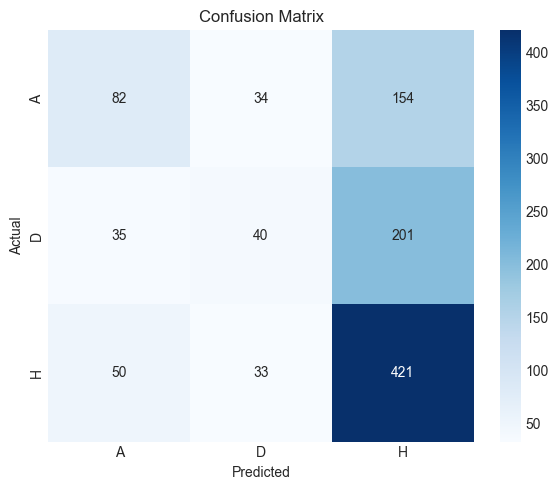

In [15]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names, ax=ax
)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

/var/folders/hv/75vn6rzj4kz6r82p8q8x02q00000gn/T/ipykernel_64791/2334613010.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='importance', y='feature', palette='viridis', ax=ax)


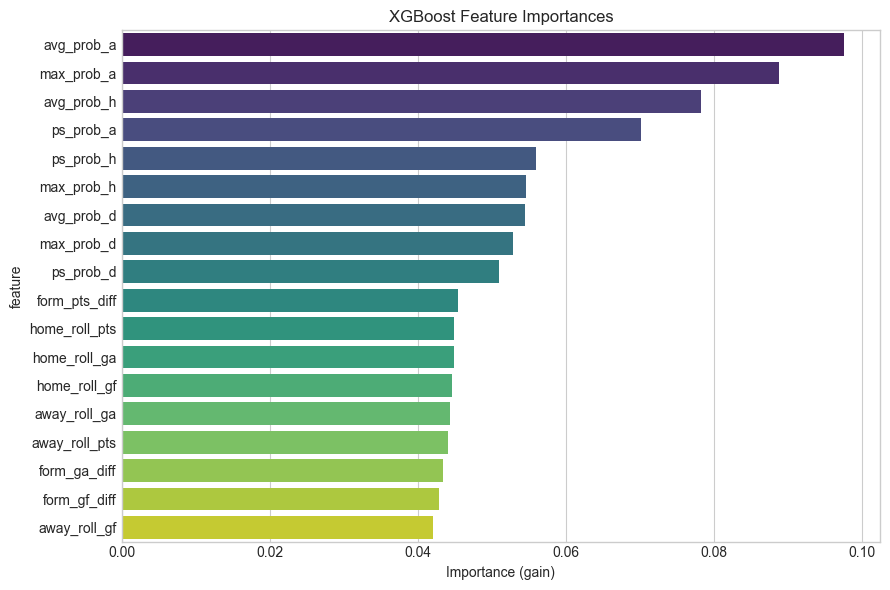

,feature,importance
5,avg_prob_a,0.097544
8,max_prob_a,0.088835
3,avg_prob_h,0.078215
2,ps_prob_a,0.070201
0,ps_prob_h,0.055925
6,max_prob_h,0.054583
4,avg_prob_d,0.054439
7,max_prob_d,0.052810
1,ps_prob_d,0.050988
15,form_pts_diff,0.045450


In [16]:
# Feature importances
importance_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=importance_df, x='importance', y='feature', palette='viridis', ax=ax)
ax.set_title('XGBoost Feature Importances')
ax.set_xlabel('Importance (gain)')
plt.tight_layout()
plt.show()

importance_df

## 8. Single-Match Prediction Example

In [17]:
# Predict for the first row in the test set
sample = X_test.iloc[[0]]
proba = model.predict_proba(sample)[0]
actual = le.inverse_transform([y_test.iloc[0]])[0]

print('Predicted probabilities:')
for cls, p in zip(class_names, proba):
    print(f'  {cls}: {p:.3f}')
print(f'\nPredicted: {le.inverse_transform([y_pred[0]])[0]}')
print(f'Actual:    {actual}')

Predicted probabilities:
  A: 0.340
  D: 0.298
  H: 0.362

Predicted: H
Actual:    A
